<a href="https://colab.research.google.com/github/zeynepuygrr/softito_hw/blob/main/21_09_2026odev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beton Basınç Dayanımı Tahmini
**Veri seti:** UCI Machine Learning Repository — Concrete Compressive Strength (id=165, Yeh 1998)

**Hedef:** Betonun içeriğinden (çimento, su, katkılar, yaş vb.) basınç dayanımını (MPa) tahmin etmek.

In [ ]:
!pip install ucimlrepo -q

In [ ]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print(f"python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
seaborn: 0.13.2
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1


## 1. Veri setini UCI'dan yükleme

In [ ]:
from ucimlrepo import fetch_ucirepo

beton = fetch_ucirepo(id=165)

X_reg = beton.data.features
y_reg = beton.data.targets.iloc[:, 0]   # DataFrame -> Series
y_reg.name = "hedef"

print(X_reg.shape, y_reg.shape)
X_reg.head()

(1030, 8) (1030,)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [ ]:
pd.concat([X_reg, y_reg], axis=1).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   hedef               1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [ ]:
pd.concat([X_reg, y_reg], axis=1).describe().round(2)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,hedef
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.35,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.80,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.40,968.00,779.50,28.00,34.44
75%,350.00,142.95,118.30,192.00,10.20,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


## 2. Keşifsel analiz: hedef dağılımı ve korelasyon

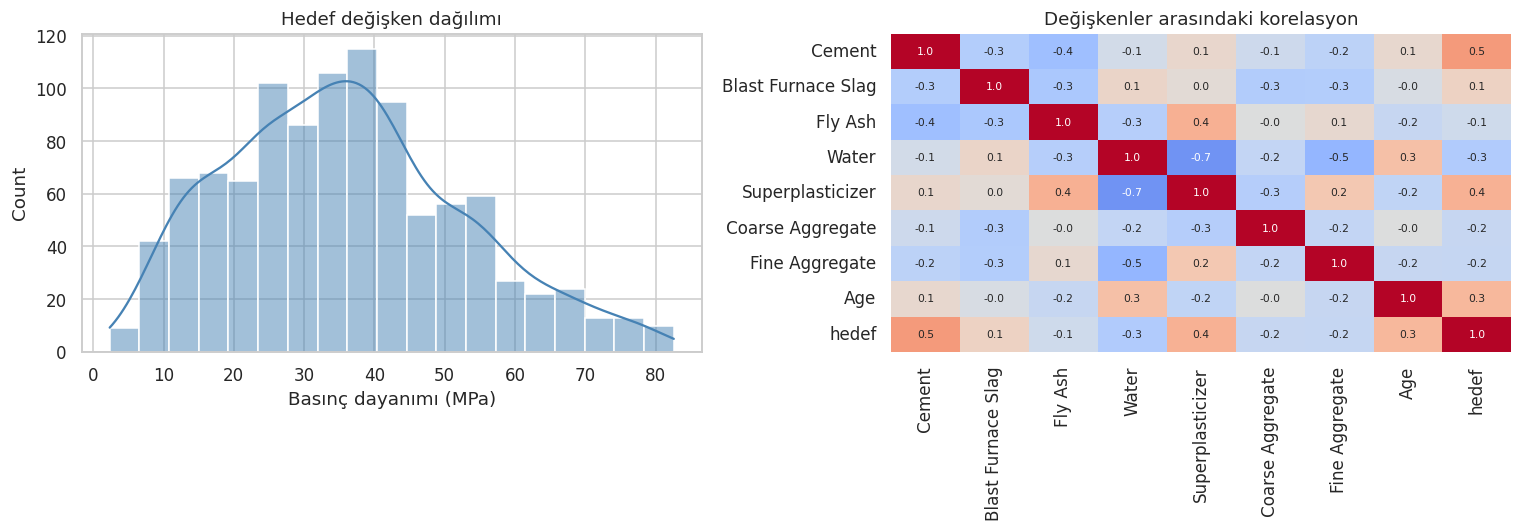

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(y_reg, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Hedef değişken dağılımı")
axes[0].set_xlabel("Basınç dayanımı (MPa)")

corr = pd.concat([X_reg, y_reg], axis=1).corr()
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            ax=axes[1], cbar=False, annot_kws={"size": 7})
axes[1].set_title("Değişkenler arasındaki korelasyon")

plt.tight_layout()
plt.show()

## 3. Eğitim / test ayırma

In [ ]:
from sklearn.model_selection import train_test_split

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)
print(f"Eğitim: {Xr_train.shape[0]} | Test: {Xr_test.shape[0]}")

Eğitim: 824 | Test: 206


## 4. Baseline ve Doğrusal Regresyon
Baseline her zaman eğitim ortalamasını tahmin eder. Modelimiz bunu geçemiyorsa işe yaramıyor demektir. İkisi de **test kümesinde** kıyaslanır.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean").fit(Xr_train, yr_train)
linear = LinearRegression().fit(Xr_train, yr_train)

def regresyon_raporu(model, X, y, ad):
    tahmin = model.predict(X)
    return {
        "Model": ad,
        "MAE": mean_absolute_error(y, tahmin),
        "MSE": mean_squared_error(y, tahmin),
        "RMSE": np.sqrt(mean_squared_error(y, tahmin)),
        "R2": r2_score(y, tahmin),
    }

sonuc = pd.DataFrame([
    regresyon_raporu(baseline, Xr_test, yr_test, "Baseline"),
    regresyon_raporu(linear, Xr_test, yr_test, "Linear"),
]).set_index("Model").round(3)
sonuc

,MAE,MSE,RMSE,R2
Model,,,,
Baseline,13.052,257.717,16.054,-0.000
Linear,7.746,95.971,9.796,0.628


## 5. Katsayılar ve Gerçek vs. Tahmin

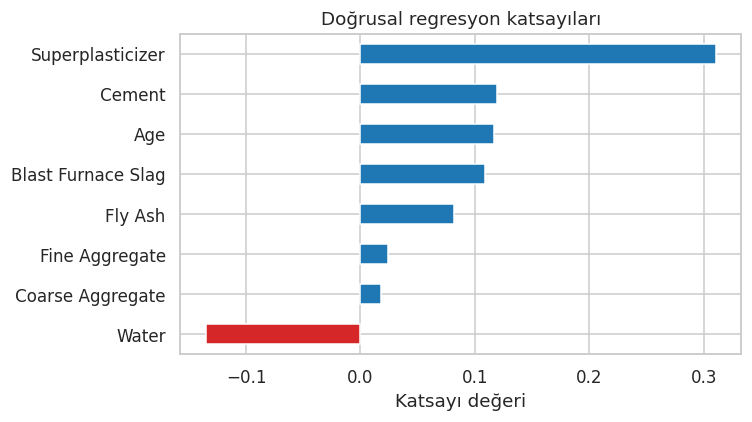

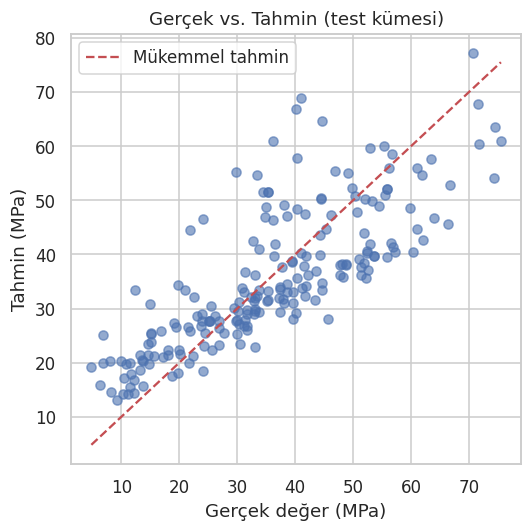

In [ ]:
katsayilar = pd.Series(linear.coef_, index=X_reg.columns).sort_values()

plt.figure(figsize=(7, 4))
katsayilar.plot(kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red"))
plt.title("Doğrusal regresyon katsayıları")
plt.xlabel("Katsayı değeri")
plt.tight_layout()
plt.show()

tahmin = linear.predict(Xr_test)
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, tahmin, alpha=0.6)
lim = [yr_test.min(), yr_test.max()]
plt.plot(lim, lim, "r--", label="Mükemmel tahmin")
plt.xlabel("Gerçek değer (MPa)")
plt.ylabel("Tahmin (MPa)")
plt.title("Gerçek vs. Tahmin (test kümesi)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Ridge ve Lasso (ölçeklendirme ile)
Özelliklerin birimleri/ölçekleri farklı (ör. `Age` gün, `Water` kg/m³), bu yüzden `StandardScaler` kullanıyoruz.

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modeller = {
    "Doğrusal": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=1.0)),
}

satirlar = []
for ad, m in modeller.items():
    m.fit(Xr_train, yr_train)
    satirlar.append(regresyon_raporu(m, Xr_test, yr_test, ad))

pd.DataFrame(satirlar).set_index("Model").round(3)

,MAE,MSE,RMSE,R2
Model,,,,
Doğrusal,7.746,95.971,9.796,0.628
Ridge,7.752,95.965,9.796,0.628
Lasso,8.716,112.369,10.600,0.564


In [ ]:
lasso = modeller["Lasso"].named_steps["lasso"]
pd.Series(lasso.coef_, index=X_reg.columns).round(2).to_frame("Lasso katsayıları").T

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
Lasso katsayıları,7.58,4.18,0.0,-2.89,3.23,-0.0,-0.05,5.4
